In [1]:
import pandas as pd 
import requests 
import numpy as np 
import json, os, time, pdb 

import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
import seaborn as sns
sns.set_theme() 

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, RocCurveDisplay, roc_curve, brier_score_loss

import statsmodels.api as sm 

from util_data_funcs import *


def save_graph_fig(ax_input, filename):
    fig = ax_input.get_figure()
    fig.savefig(filename, dpi=300, bbox_inches='tight')


def get_winner(df):
    if df['home_team_score'] > df['away_team_score']:
        return df['home_team'], 'home'
    elif df['home_team_score'] < df['away_team_score']:
        return df['away_team'], 'away'
    else:
        return 'Tie', 'Tie'
    

def format_score_diff_feats(df):
    df[['winning_team', 'winning_side']] = df.apply(get_winner, axis=1, result_type='expand')
    df['score_diff'] = np.abs(df['home_team_score'] - df['away_team_score'])
    return df 


def add_per_game_metrics(input_df):
    checker = input_df.groupby('league_season')[
        ['home_yellow_cards', 'away_yellow_cards', 'home_red_cards', 'away_red_cards']
    ].sum().reset_index().merge(
        input_df.groupby('league_season')['game_id'].nunique().reset_index(), 
        on='league_season', 
        how='left'
    )

    checker['total_yc'] = checker['home_yellow_cards'] + checker['away_yellow_cards']
    checker['total_rc'] = checker['home_red_cards'] + checker['away_red_cards']

    checker['yc_per_game'] = checker['total_yc'] / checker['game_id']
    checker['rc_per_game'] = checker['total_rc'] / checker['game_id']

    checker['home_yc_per_game'] = checker['home_yellow_cards'] / checker['game_id']
    checker['away_yc_per_game'] = checker['away_yellow_cards'] / checker['game_id']

    checker['home_rc_per_game'] = checker['home_red_cards'] / checker['game_id']
    checker['away_rc_per_game'] = checker['away_red_cards'] / checker['game_id']

    return checker 


def get_game_quarters(df):
    q_val = 'first_half'
    if df['Time'] <= 40:
        return q_val
    elif df['Time'] > 40 and df['Time'] <= 60:
        return 'third_quarter'
    elif df['Time'] > 60:
        return 'fourth_quarter'
    else:
        q_val


def get_match_time_metrics(df, event_name, col_name):

    df.loc[(df['game_period'] == 'fourth_quarter') & (df['Event_Type'] == event_name), 'Last_20_{}'.format(col_name)] = df['Player']
    df.loc[(df['game_period'] != 'fourth_quarter') | (df['Event_Type'] != event_name), 'Last_20_{}'.format(col_name)] = 0

    df.loc[(df['game_period'] == 'third_quarter') & (df['Event_Type'] == event_name), 'Q3_{}'.format(col_name)] = df['Player']
    df.loc[(df['game_period'] != 'third_quarter') | (df['Event_Type'] != event_name), 'Q3_{}'.format(col_name)] = 0

    df.loc[(df['game_period'] == 'first_half') & (df['Event_Type'] == event_name), 'H1_{}'.format(col_name)] = df['Player']
    df.loc[(df['game_period'] != 'first_half') | (df['Event_Type'] != event_name), 'H1_{}'.format(col_name)] = 0

    return df 




t14_game_df, t14_player_df, t14_team_df = gather_dataframes('T14')
urc_game_df, urc_player_df, urc_team_df = gather_dataframes('URC')
prem_game_df, prem_player_df, prem_team_df = gather_dataframes('Prem')
# sr_game_df, sr_player_df, sr_team_df = gather_dataframes('SR')
six_nat_game_df, six_nat_player_df, six_nat_team_df = gather_dataframes('SixNat')
# rchamp_game_df, rchamp_player_df, rchamp_team_df = gather_dataframes('RChamp')

In [2]:
total_club_df = pd.concat(
    [urc_game_df, t14_game_df, prem_game_df]
    # [t14_game_df, prem_game_df]
)

total_club_df = format_score_diff_feats(total_club_df)

In [38]:
total_club_df[(total_club_df['league_id'] == 267979) & (total_club_df['home_red_cards'] >= 1)]['league_season'].value_counts()

league_season
2020-2021    12
2021-2022    11
2022-2023     6
2016-2017     6
2023-2024     3
2014-2015     3
2015-2016     3
2017-2018     2
2013-2014     2
2019-2020     2
2018-2019     1
Name: count, dtype: int64

In [45]:
total_club_df[(total_club_df['league_id'] == 267979) & (total_club_df['league_season'] == '2017-2018')]['game_id']

0      291620
1      291618
2      291612
3      291606
4      291599
        ...  
131    291683
132    291640
133    291679
134    291664
135    291648
Name: game_id, Length: 136, dtype: int64

In [48]:
total_club_df['game_id'].nunique()

4911

In [55]:
14*26/2

182.0

In [59]:
total_club_df[total_club_df['league_id'] == 270557].groupby(['season', 'league_id'])['game_id'].nunique().reset_index()


,season,league_id,game_id
0,2011,270557,139
1,2012,270557,139
2,2013,270557,128
3,2014,270557,136
4,2015,270557,128
5,2016,270557,144
6,2017,270557,147
7,2018,270557,112
8,2019,270557,82
9,2020,270557,38


In [61]:
total_club_df[total_club_df['league_id'] == 267979].groupby(['league_season', 'league_id'])['game_id'].nunique().reset_index()

,league_season,league_id,game_id
0,2012-2013,267979,63
1,2013-2014,267979,134
2,2014-2015,267979,132
3,2015-2016,267979,135
4,2016-2017,267979,135
5,2017-2018,267979,136
6,2018-2019,267979,65
7,2019-2020,267979,60
8,2020-2021,267979,159
9,2021-2022,267979,159


In [3]:
f_path = 'formed_data/team_data_v2'
old_team_data = [f_path+'/'+i for i in os.listdir(f_path)]
old_team_df = pd.concat(list(map(pd.read_csv, old_team_data)))
old_team_df.drop('Unnamed: 0', axis=1, inplace=True)

team_info_df = pd.concat(
    [urc_team_df, t14_team_df, prem_team_df]
    # [t14_game_df, prem_game_df]
)

comb_team_info = pd.concat([team_info_df, old_team_df])
comb_team_info

,team_name,team_link,team_id,rank,season,league_id,team_abbr
0,Leinster,/rugby/team/_/id/25924/leinster,25924.0,1.0,2020,270557.0,NaN
1,Ulster,/rugby/team/_/id/25926/ulster,25926.0,2.0,2020,270557.0,NaN
2,Glasgow Warriors,/rugby/team/_/id/25952/glasgow-warriors,25952.0,3.0,2020,270557.0,NaN
3,Cheetahs,/rugby/team/_/id/25955/cheetahs,25955.0,4.0,2020,270557.0,NaN
4,Dragons,/rugby/team/_/id/25967/dragons,25967.0,5.0,2020,270557.0,NaN
...,...,...,...,...,...,...,...
7,Sale Sharks,NaN,NaN,8.0,2018,267979.0,SAL
8,Northampton Saints,NaN,NaN,9.0,2018,267979.0,NOR
9,Harlequins,NaN,NaN,10.0,2018,267979.0,HAR
10,Worcester Warriors,NaN,NaN,11.0,2018,267979.0,WORCS


In [4]:
match_comm_path = 'formed_data/match_comm_data'
comm_files = [match_comm_path+'/'+i for i in os.listdir(match_comm_path) if '_v2' in i]
comm_df = pd.concat(list(map(pd.read_csv, comm_files)))

comm_df = comm_df.drop_duplicates().reset_index(drop=True)
comm_df['game_period'] = comm_df.apply(get_game_quarters, axis=1)

In [ ]:
comm_df

3946

In [46]:
comm_df[comm_df['game_id'] == 291620]

,game_id,league_id,Time,Team,Player,Event_Type,Home_Score,Away_Score,game_period


In [5]:
rc_comm_df = comm_df[(comm_df['Event_Type'].isin(['Red_Card', 'Yellow_Card']))]
rc_comm_df

,game_id,league_id,Time,Team,Player,Event_Type,Home_Score,Away_Score,game_period
1,597814,270559,76,Stade Toulousain,Juan Cruz Mallia,Yellow_Card,22.0,3.0,fourth_quarter
10,597814,270559,55,Stade Toulousain,Piula Fa'asalele,Yellow_Card,22.0,3.0,third_quarter
11,597814,270559,54,La Rochelle,Thomas Lavault,Red_Card,22.0,3.0,third_quarter
43,597814,270559,14,Stade Toulousain,Joshua Brennan,Yellow_Card,NaN,NaN,first_half
87,597808,270559,38,Toulon,Emerick Setiano,Yellow_Card,12.0,14.0,first_half
...,...,...,...,...,...,...,...,...,...
185346,290547,270557,65,Edinburgh,Allan Dell,Yellow_Card,3.0,17.0,fourth_quarter
185411,290555,270557,75,Benetton Treviso,Tiziano Pasquali,Yellow_Card,3.0,19.0,fourth_quarter
185443,290555,270557,39,Benetton Treviso,Marco Fuser,Yellow_Card,3.0,10.0,first_half
185482,290496,270557,36,Dragons,Sarel Pretorius,Yellow_Card,10.0,8.0,first_half


In [6]:
first_card_df = rc_comm_df.groupby(['game_id', 'Team', 'Event_Type'])['Time'].min().reset_index()
first_card_df['first_card_flag'] = 1
first_card_df.head()

,game_id,Team,Event_Type,Time,first_card_flag
0,119090,Brive,Yellow_Card,32,1
1,119091,Montpellier Herault,Yellow_Card,35,1
2,119091,Racing 92,Yellow_Card,46,1
3,119092,Biarritz Olympique,Yellow_Card,24,1
4,119092,Toulon,Yellow_Card,14,1


In [7]:
first_card_df[first_card_df['game_id'] == 597814]

,game_id,Team,Event_Type,Time,first_card_flag
3898,597814,La Rochelle,Red_Card,54,1
3899,597814,Stade Toulousain,Yellow_Card,14,1


In [8]:
rc_comm_df[rc_comm_df['game_id'] == 597814]

,game_id,league_id,Time,Team,Player,Event_Type,Home_Score,Away_Score,game_period
1,597814,270559,76,Stade Toulousain,Juan Cruz Mallia,Yellow_Card,22.0,3.0,fourth_quarter
10,597814,270559,55,Stade Toulousain,Piula Fa'asalele,Yellow_Card,22.0,3.0,third_quarter
11,597814,270559,54,La Rochelle,Thomas Lavault,Red_Card,22.0,3.0,third_quarter
43,597814,270559,14,Stade Toulousain,Joshua Brennan,Yellow_Card,NaN,NaN,first_half


In [9]:
rc_comm_flag_df = rc_comm_df.merge(first_card_df, how='left', on=['game_id', 'Team', 'Time', 'Event_Type'])
rc_comm_flag_df.loc[rc_comm_flag_df['first_card_flag'].isnull(), 'first_card_flag'] = 0
rc_comm_flag_df

,game_id,league_id,Time,Team,Player,Event_Type,Home_Score,Away_Score,game_period,first_card_flag
0,597814,270559,76,Stade Toulousain,Juan Cruz Mallia,Yellow_Card,22.0,3.0,fourth_quarter,0.0
1,597814,270559,55,Stade Toulousain,Piula Fa'asalele,Yellow_Card,22.0,3.0,third_quarter,0.0
2,597814,270559,54,La Rochelle,Thomas Lavault,Red_Card,22.0,3.0,third_quarter,1.0
3,597814,270559,14,Stade Toulousain,Joshua Brennan,Yellow_Card,NaN,NaN,first_half,1.0
4,597808,270559,38,Toulon,Emerick Setiano,Yellow_Card,12.0,14.0,first_half,1.0
...,...,...,...,...,...,...,...,...,...,...
5186,290547,270557,65,Edinburgh,Allan Dell,Yellow_Card,3.0,17.0,fourth_quarter,1.0
5187,290555,270557,75,Benetton Treviso,Tiziano Pasquali,Yellow_Card,3.0,19.0,fourth_quarter,0.0
5188,290555,270557,39,Benetton Treviso,Marco Fuser,Yellow_Card,3.0,10.0,first_half,1.0
5189,290496,270557,36,Dragons,Sarel Pretorius,Yellow_Card,10.0,8.0,first_half,1.0


In [10]:
rc_game_total = total_club_df[total_club_df['game_id'].isin(first_card_df['game_id'].unique())]
rc_game_total

,game_id,league_id,home_team,home_team_score,away_team,away_team_score,home_tries,away_tries,home_conversions,away_conversions,...,away_scrum_total_num,away_scrum_won_percent,away_lineout_num,away_lineout_total_num,away_lineout_won_percent,date_formatted,league_season,winning_team,winning_side,score_diff
1,167046,270557,Ulster,27,Leinster,19,2.0,1.0,3.0,1.0,...,3.0,0.66,11.0,11.0,1.00,2012-12-21,2012-2013,Ulster,home,8
2,167039,270557,Leinster,37,Zebre,7,5.0,1.0,3.0,1.0,...,8.0,0.87,4.0,7.0,0.57,2012-12-01,2012-2013,Leinster,home,30
3,167035,270557,Glasgow Warriors,0,Leinster,6,0.0,0.0,0.0,0.0,...,8.0,0.87,14.0,17.0,0.82,2012-11-23,2012-2013,Leinster,away,6
4,167027,270557,Ospreys,19,Leinster,10,1.0,1.0,1.0,1.0,...,7.0,0.85,12.0,15.0,0.80,2012-11-04,2012-2013,Ospreys,home,9
5,167020,270557,Leinster,59,Cardiff Blues,22,9.0,3.0,7.0,2.0,...,5.0,1.00,7.0,9.0,0.77,2012-10-27,2012-2013,Leinster,home,37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,597095,267979,Newcastle Falcons,3,Harlequins,24,0.0,4.0,0.0,2.0,...,6.0,1.00,12.0,13.0,0.92,2024-01-05,2023-2024,Harlequins,away,21
87,597133,267979,Leicester Tigers,40,Exeter Chiefs,22,4.0,3.0,4.0,2.0,...,6.0,1.00,7.0,10.0,0.70,2024-05-18,2023-2024,Leicester Tigers,home,18
89,597107,267979,Exeter Chiefs,25,Newcastle Falcons,16,4.0,1.0,1.0,1.0,...,4.0,0.75,10.0,10.0,1.00,2024-03-23,2023-2024,Exeter Chiefs,home,9
90,597112,267979,Newcastle Falcons,13,Leicester Tigers,19,1.0,3.0,1.0,2.0,...,5.0,0.60,16.0,19.0,0.84,2024-03-29,2023-2024,Leicester Tigers,away,6


In [11]:
rc_comm_filt = rc_comm_flag_df[rc_comm_flag_df['first_card_flag'] == 1].reset_index(drop=True)
rc_comm_filt[['Home_Score', 'Away_Score']] = rc_comm_filt[['Home_Score', 'Away_Score']].fillna(0.0)
rc_comm_filt

,game_id,league_id,Time,Team,Player,Event_Type,Home_Score,Away_Score,game_period,first_card_flag
0,597814,270559,54,La Rochelle,Thomas Lavault,Red_Card,22.0,3.0,third_quarter,1.0
1,597814,270559,14,Stade Toulousain,Joshua Brennan,Yellow_Card,0.0,0.0,first_half,1.0
2,597808,270559,38,Toulon,Emerick Setiano,Yellow_Card,12.0,14.0,first_half,1.0
3,597808,270559,38,Stade Toulousain,Rodrigue Neti,Yellow_Card,12.0,14.0,first_half,1.0
4,597786,270559,79,Stade Toulousain,Lucas Tauzin,Yellow_Card,31.0,16.0,fourth_quarter,1.0
...,...,...,...,...,...,...,...,...,...,...
4045,290547,270557,72,Dragons,Charlie Davies,Yellow_Card,3.0,20.0,fourth_quarter,1.0
4046,290547,270557,65,Edinburgh,Allan Dell,Yellow_Card,3.0,17.0,fourth_quarter,1.0
4047,290555,270557,39,Benetton Treviso,Marco Fuser,Yellow_Card,3.0,10.0,first_half,1.0
4048,290496,270557,36,Dragons,Sarel Pretorius,Yellow_Card,10.0,8.0,first_half,1.0


In [12]:
rc_game_total[rc_game_total['away_red_cards'] > 0][['game_id', 'home_red_cards', 'away_red_cards', 'home_yellow_cards', 'away_yellow_cards']]

,game_id,home_red_cards,away_red_cards,home_yellow_cards,away_yellow_cards
13,167054,0.0,2.0,0.0,3.0
18,167013,0.0,1.0,0.0,1.0
63,167041,0.0,1.0,0.0,1.0
98,167058,0.0,1.0,0.0,0.0
110,167074,0.0,1.0,0.0,1.0
...,...,...,...,...,...
147,593681,0.0,1.0,1.0,0.0
19,294904,0.0,1.0,0.0,1.0
29,597069,0.0,1.0,0.0,0.0
50,597137,0.0,1.0,0.0,0.0


In [13]:
rc_game_total

,game_id,league_id,home_team,home_team_score,away_team,away_team_score,home_tries,away_tries,home_conversions,away_conversions,...,away_scrum_total_num,away_scrum_won_percent,away_lineout_num,away_lineout_total_num,away_lineout_won_percent,date_formatted,league_season,winning_team,winning_side,score_diff
1,167046,270557,Ulster,27,Leinster,19,2.0,1.0,3.0,1.0,...,3.0,0.66,11.0,11.0,1.00,2012-12-21,2012-2013,Ulster,home,8
2,167039,270557,Leinster,37,Zebre,7,5.0,1.0,3.0,1.0,...,8.0,0.87,4.0,7.0,0.57,2012-12-01,2012-2013,Leinster,home,30
3,167035,270557,Glasgow Warriors,0,Leinster,6,0.0,0.0,0.0,0.0,...,8.0,0.87,14.0,17.0,0.82,2012-11-23,2012-2013,Leinster,away,6
4,167027,270557,Ospreys,19,Leinster,10,1.0,1.0,1.0,1.0,...,7.0,0.85,12.0,15.0,0.80,2012-11-04,2012-2013,Ospreys,home,9
5,167020,270557,Leinster,59,Cardiff Blues,22,9.0,3.0,7.0,2.0,...,5.0,1.00,7.0,9.0,0.77,2012-10-27,2012-2013,Leinster,home,37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,597095,267979,Newcastle Falcons,3,Harlequins,24,0.0,4.0,0.0,2.0,...,6.0,1.00,12.0,13.0,0.92,2024-01-05,2023-2024,Harlequins,away,21
87,597133,267979,Leicester Tigers,40,Exeter Chiefs,22,4.0,3.0,4.0,2.0,...,6.0,1.00,7.0,10.0,0.70,2024-05-18,2023-2024,Leicester Tigers,home,18
89,597107,267979,Exeter Chiefs,25,Newcastle Falcons,16,4.0,1.0,1.0,1.0,...,4.0,0.75,10.0,10.0,1.00,2024-03-23,2023-2024,Exeter Chiefs,home,9
90,597112,267979,Newcastle Falcons,13,Leicester Tigers,19,1.0,3.0,1.0,2.0,...,5.0,0.60,16.0,19.0,0.84,2024-03-29,2023-2024,Leicester Tigers,away,6


In [14]:
yellow_total_base = rc_game_total[
    rc_game_total['game_id'].isin(
        rc_comm_filt[rc_comm_filt['Event_Type'] == 'Yellow_Card']['game_id'].unique())
]

red_total_base = rc_game_total[
    rc_game_total['game_id'].isin(
        rc_comm_filt[rc_comm_filt['Event_Type'] == 'Red_Card']['game_id'].unique())
]

yellow_score = yellow_total_base[
    [
        'game_id', 'league_id','league_season','home_team', 'away_team', 
        'home_team_score', 'away_team_score'
    ]
].merge(
    rc_comm_filt[rc_comm_filt['Event_Type'] == 'Yellow_Card'][
        ['game_id', 'Time', 'Team', 'Home_Score', 'Away_Score']
    ],
    how='left',
    left_on=['game_id', 'home_team'],
    right_on=['game_id', 'Team'],
    suffixes=('', '_home_yellow')
).merge(
    rc_comm_filt[rc_comm_filt['Event_Type'] == 'Yellow_Card'][
        ['game_id', 'Time', 'Team', 'Home_Score', 'Away_Score']
    ],
    how='left',
    left_on=['game_id', 'away_team'],
    right_on=['game_id', 'Team'],
    suffixes=('', '_away_yellow')
)


red_score = red_total_base[
    [
        'game_id', 'league_id','league_season','home_team', 'away_team', 
        'home_team_score', 'away_team_score'
    ]
].merge(
    rc_comm_filt[rc_comm_filt['Event_Type'] == 'Red_Card'][
        ['game_id', 'Time', 'Team', 'Home_Score', 'Away_Score']
    ],
    how='left',
    left_on=['game_id', 'home_team'],
    right_on=['game_id', 'Team'],
    suffixes=('', '_home_red')
).merge(
    rc_comm_filt[rc_comm_filt['Event_Type'] == 'Red_Card'][
        ['game_id', 'Time', 'Team', 'Home_Score', 'Away_Score']
    ],
    how='left',
    left_on=['game_id', 'away_team'],
    right_on=['game_id', 'Team'],
    suffixes=('', '_away_red')
)

# red_score_track = 

In [15]:
yellow_score = yellow_score[~yellow_score['Team'].isnull()].reset_index(drop=True)
red_score = red_score[~red_score['Team'].isnull()].reset_index(drop=True)

In [16]:
red_score['home_points_after_home_red'] = red_score['home_team_score'] - red_score['Home_Score']
red_score['away_points_after_home_red'] = red_score['away_team_score'] - red_score['Away_Score']

red_score['home_points_after_away_red'] = red_score['home_team_score'] - red_score['Home_Score_away_red']
red_score['away_points_after_away_red'] = red_score['away_team_score'] - red_score['Away_Score_away_red']

yellow_score['home_points_after_home_yellow'] = yellow_score['home_team_score'] - yellow_score['Home_Score']
yellow_score['away_points_after_home_yellow'] = yellow_score['away_team_score'] - yellow_score['Away_Score']

yellow_score['home_points_after_away_yellow'] = yellow_score['home_team_score'] - yellow_score['Home_Score_away_yellow']
yellow_score['away_points_after_away_yellow'] = yellow_score['away_team_score'] - yellow_score['Away_Score_away_yellow']



In [35]:
rc_game_total[rc_game_total['league_id'] == 267979]['league_season'].value_counts()

league_season
2020-2021    113
2021-2022    107
2022-2023     89
2023-2024     67
2019-2020     40
Name: count, dtype: int64

In [17]:
yellow_score

,game_id,league_id,league_season,home_team,away_team,home_team_score,away_team_score,Time,Team,Home_Score,Away_Score,Time_away_yellow,Team_away_yellow,Home_Score_away_yellow,Away_Score_away_yellow,home_points_after_home_yellow,away_points_after_home_yellow,home_points_after_away_yellow,away_points_after_away_yellow
0,167046,270557,2012-2013,Ulster,Leinster,27,19,70.0,Ulster,20.0,12.0,NaN,NaN,NaN,NaN,7.0,7.0,NaN,NaN
1,167035,270557,2012-2013,Glasgow Warriors,Leinster,0,6,24.0,Glasgow Warriors,0.0,3.0,80.0,Leinster,0.0,6.0,0.0,3.0,0.0,0.0
2,167027,270557,2012-2013,Ospreys,Leinster,19,10,51.0,Ospreys,9.0,10.0,NaN,NaN,NaN,NaN,10.0,0.0,NaN,NaN
3,167009,270557,2012-2013,Connacht,Leinster,34,6,63.0,Connacht,22.0,6.0,30.0,Leinster,14.0,6.0,12.0,0.0,20.0,0.0
4,167042,270557,2012-2013,Ospreys,Cardiff Blues,33,12,50.0,Ospreys,23.0,9.0,76.0,Cardiff Blues,26.0,12.0,10.0,3.0,7.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1556,597125,267979,2023-2024,Bristol Rugby,Saracens,20,41,13.0,Bristol Rugby,10.0,0.0,50.0,Saracens,13.0,26.0,10.0,41.0,7.0,15.0
1557,597109,267979,2023-2024,Saracens,Harlequins,52,7,79.0,Saracens,52.0,7.0,14.0,Harlequins,7.0,0.0,0.0,0.0,45.0,7.0
1558,597123,267979,2023-2024,Leicester Tigers,Bristol Rugby,19,21,22.0,Leicester Tigers,7.0,0.0,16.0,Bristol Rugby,0.0,0.0,12.0,21.0,19.0,21.0
1559,597126,267979,2023-2024,Exeter Chiefs,Harlequins,58,26,49.0,Exeter Chiefs,28.0,21.0,NaN,NaN,NaN,NaN,30.0,5.0,NaN,NaN


In [18]:
rc_comm_season = rc_comm_filt.merge(rc_game_total[['game_id', 'league_season']].drop_duplicates(), on=['game_id'], how='left')
rc_comm_season

,game_id,league_id,Time,Team,Player,Event_Type,Home_Score,Away_Score,game_period,first_card_flag,league_season
0,597814,270559,54,La Rochelle,Thomas Lavault,Red_Card,22.0,3.0,third_quarter,1.0,2023-2024
1,597814,270559,14,Stade Toulousain,Joshua Brennan,Yellow_Card,0.0,0.0,first_half,1.0,2023-2024
2,597808,270559,38,Toulon,Emerick Setiano,Yellow_Card,12.0,14.0,first_half,1.0,2023-2024
3,597808,270559,38,Stade Toulousain,Rodrigue Neti,Yellow_Card,12.0,14.0,first_half,1.0,2023-2024
4,597786,270559,79,Stade Toulousain,Lucas Tauzin,Yellow_Card,31.0,16.0,fourth_quarter,1.0,2023-2024
...,...,...,...,...,...,...,...,...,...,...,...
4045,290547,270557,72,Dragons,Charlie Davies,Yellow_Card,3.0,20.0,fourth_quarter,1.0,2016-2017
4046,290547,270557,65,Edinburgh,Allan Dell,Yellow_Card,3.0,17.0,fourth_quarter,1.0,2016-2017
4047,290555,270557,39,Benetton Treviso,Marco Fuser,Yellow_Card,3.0,10.0,first_half,1.0,2016-2017
4048,290496,270557,36,Dragons,Sarel Pretorius,Yellow_Card,10.0,8.0,first_half,1.0,2016-2017


In [19]:
grouped_card_times = rc_comm_season.groupby(['league_season', 'league_id','Time'])['Event_Type'].value_counts().reset_index()
grouped_rc_times = grouped_card_times[grouped_card_times['Event_Type'] == 'Red_Card']

In [20]:
grouped_rc_times

,league_season,league_id,Time,Event_Type,count
114,2011-2012,270557,30,Red_Card,1
162,2011-2012,270557,81,Red_Card,1
180,2011-2012,270559,23,Red_Card,1
185,2011-2012,270559,27,Red_Card,1
188,2011-2012,270559,29,Red_Card,2
...,...,...,...,...,...
2018,2023-2024,270559,25,Red_Card,1
2031,2023-2024,270559,39,Red_Card,1
2036,2023-2024,270559,46,Red_Card,1
2038,2023-2024,270559,47,Red_Card,1


array([[<Axes: title={'center': 'Time'}>]], dtype=object)

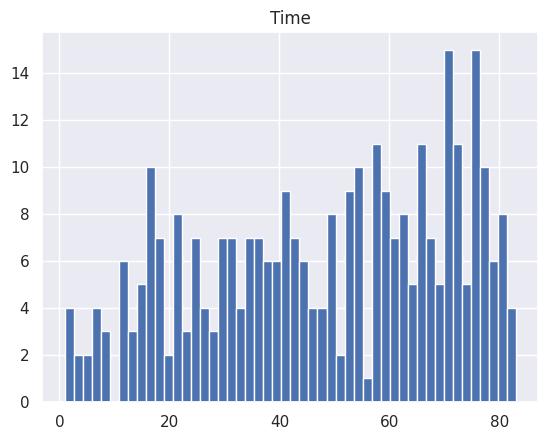

In [21]:
grouped_rc_times.hist('Time', bins=50)

array([[<Axes: title={'center': 'Time'}>]], dtype=object)

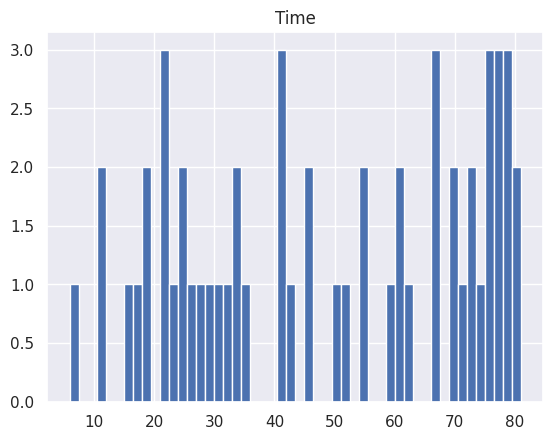

In [22]:
grouped_rc_times[grouped_rc_times['league_season'].isin(['2011-2012', '2012-2013', '2013-2014', '2014-2015', '2015-2016'])].hist('Time', bins=50)

<Axes: xlabel='count', ylabel='Time'>

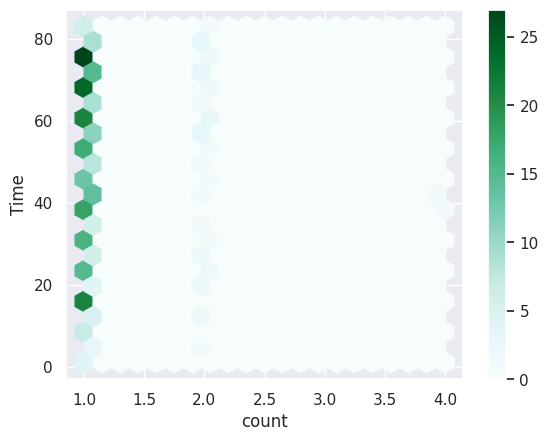

In [23]:
grouped_rc_times.plot.hexbin(x='count', y='Time', gridsize=20)

In [24]:
rc_game_total[['game_id', 'league_season']]

,game_id,league_season
1,167046,2012-2013
2,167039,2012-2013
3,167035,2012-2013
4,167027,2012-2013
5,167020,2012-2013
...,...,...
86,597095,2023-2024
87,597133,2023-2024
89,597107,2023-2024
90,597112,2023-2024


In [25]:
red_score.groupby(['league_season', 'league_id'])['home_points_after_home_red'].mean().reset_index()

,league_season,league_id,home_points_after_home_red
0,2011-2012,270559,9.000000
1,2013-2014,270557,11.500000
2,2013-2014,270559,10.000000
3,2014-2015,270557,5.800000
4,2014-2015,270559,16.166667
5,2015-2016,270559,9.375000
6,2016-2017,270557,4.333333
7,2016-2017,270559,9.555556
8,2017-2018,270557,10.666667
9,2017-2018,270559,6.928571


In [26]:
rc_game_total[rc_game_total['home_red_cards'] > 1]['game_id'].unique()

array([290260, 293195, 291420, 593247, 594162, 593669])

In [27]:
red_score[['league_season', 'game_id', 'home_points_after_home_red']].drop_duplicates()

,league_season,game_id,home_points_after_home_red
0,2023-2024,598075,0.0
1,2023-2024,598034,0.0
2,2023-2024,598058,36.0
3,2023-2024,598065,14.0
4,2023-2024,598049,0.0
...,...,...,...
164,2019-2020,294909,3.0
165,2019-2020,294940,10.0
166,2023-2024,597091,7.0
167,2023-2024,597123,0.0


In [28]:
league_red_score = red_score[
    red_score['game_id'].isin(rc_game_total[rc_game_total['home_red_cards'] >= 1]['game_id'].unique())
].groupby(['league_season', 'league_id'])[['home_points_after_home_red', 'home_points_after_away_red', 'away_points_after_home_red', 'away_points_after_away_red']].mean().reset_index()

league_red_score
# 

,league_season,league_id,home_points_after_home_red,home_points_after_away_red,away_points_after_home_red,away_points_after_away_red
0,2011-2012,270559,9.000000,7.5,7.666667,10.00
1,2013-2014,270557,11.500000,3.0,10.500000,5.00
2,2013-2014,270559,10.000000,NaN,6.000000,NaN
3,2014-2015,270557,5.800000,NaN,11.600000,NaN
4,2014-2015,270559,16.166667,NaN,17.500000,NaN
5,2015-2016,270559,9.375000,19.0,11.250000,20.00
6,2016-2017,270557,4.333333,NaN,7.666667,NaN
7,2016-2017,270559,9.555556,11.5,10.777778,9.25
8,2017-2018,270557,10.666667,NaN,9.333333,NaN
9,2017-2018,270559,6.928571,5.0,7.357143,1.00


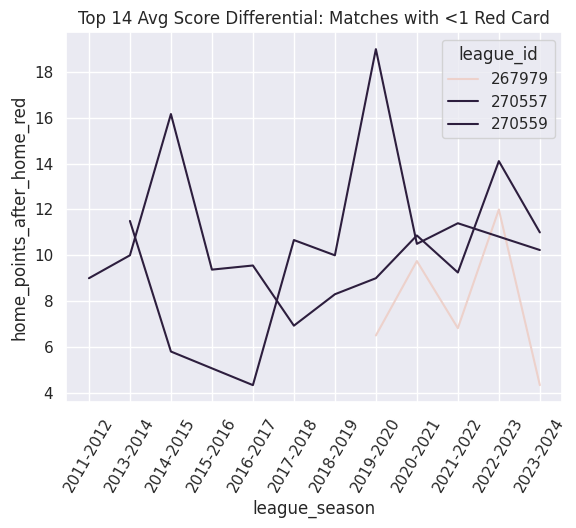

In [29]:
# fig, axes = plt.subplots(2,2, figsize=(10,2))

# color_codes = []
sns.lineplot(data=league_red_score, x='league_season', y='home_points_after_home_red', hue='league_id')


plt.title('Top 14 Avg Score Differential: Matches with <1 Red Card')
plt.xticks(rotation=60)
plt.show()

In [37]:
league_yellow_score = yellow_score[
    yellow_score['game_id'].isin(rc_game_total[rc_game_total['home_yellow_cards'] >= 1]['game_id'].unique())
].groupby(['league_season', 'league_id'])[['home_points_after_home_yellow', 'home_points_after_away_yellow']].mean().reset_index()

league_yellow_score


,league_season,league_id,home_points_after_home_yellow,home_points_after_away_yellow
0,2010-2011,270557,6.806452,12.210526
1,2010-2011,270559,12.000000,15.937500
2,2011-2012,270557,9.062500,10.694444
3,2011-2012,270559,9.487500,14.116667
4,2012-2013,270557,9.675000,11.571429
5,2013-2014,270557,7.512821,9.636364
6,2013-2014,270559,8.272727,17.777778
7,2014-2015,270557,8.400000,10.882353
8,2014-2015,270559,10.457831,16.603448
9,2015-2016,270557,6.423077,9.583333


<Axes: xlabel='league_season'>

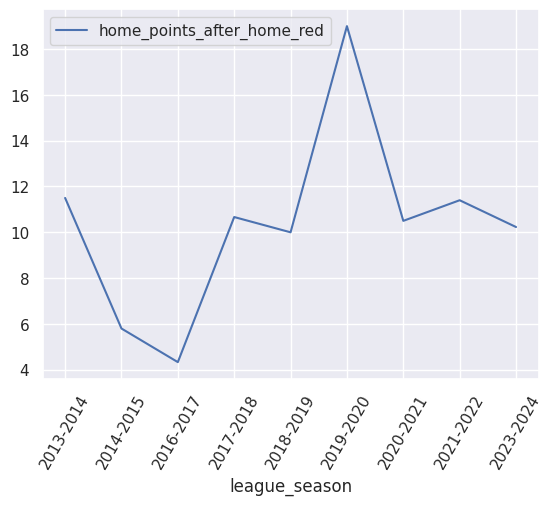

In [36]:
league_red_score[league_red_score['league_id'] == 270557].plot(x='league_season', y='home_points_after_home_red', rot=60)


In [ ]:
fig, axis = plt.Figure()

<Axes: xlabel='league_season'>

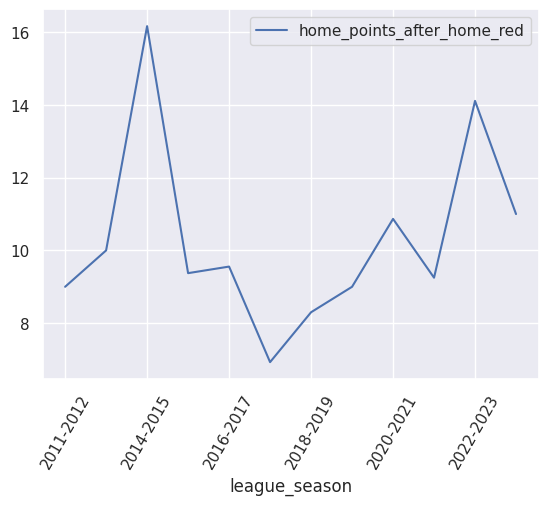

In [35]:
# yellow_score[
#     yellow_score['game_id'].isin(rc_game_total[rc_game_total['home_yellow_cards'] >= 1]['game_id'].unique())
# ].groupby('league_season')['away_points_after_home_yellow'].mean().plot(rot=60)

# yellow_score[
#     yellow_score['game_id'].isin(rc_game_total[rc_game_total['home_yellow_cards'] >= 1]['game_id'].unique())
# ].groupby('league_season')['home_points_after_home_yellow'].mean().plot(rot=60)

league_red_score[league_red_score['league_id'] == 270559].plot(x='league_season', y='home_points_after_home_red', rot=60)
# league_yellow_score[league_yellow_score['league_id'] == 270557].plot(x='league_season', y='home_points_after_home_yellow', rot=60)

<Axes: xlabel='league_season'>

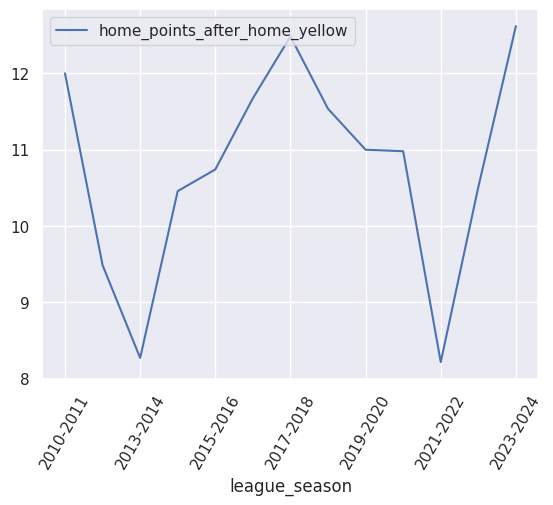

In [41]:
league_yellow_score[league_yellow_score['league_id'] == 270559].plot(x='league_season', y='home_points_after_home_yellow', rot=60)

<Axes: xlabel='league_season'>

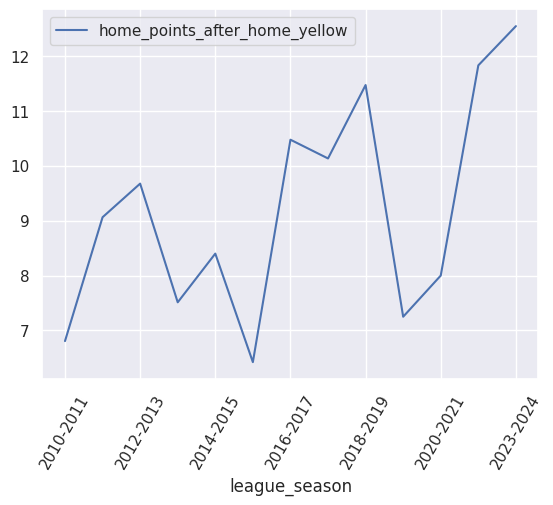

In [40]:
league_yellow_score[league_yellow_score['league_id'] == 270557].plot(x='league_season', y='home_points_after_home_yellow', rot=60)

<Axes: xlabel='league_season'>

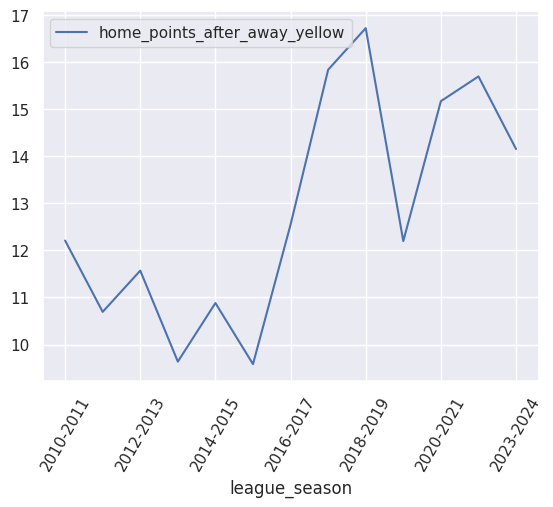

In [39]:
league_yellow_score[league_yellow_score['league_id'] == 270557].plot(x='league_season', y='home_points_after_away_yellow', rot=60)

<Axes: xlabel='league_season'>

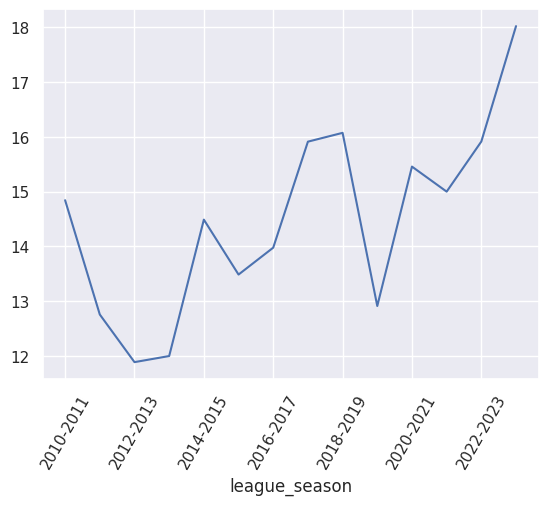

In [35]:
yellow_score[
    yellow_score['game_id'].isin(rc_game_total[rc_game_total['away_yellow_cards'] >= 1]['game_id'].unique())
].groupby('league_season')['home_points_after_away_yellow'].mean().plot(rot=60)

<Axes: xlabel='league_season'>

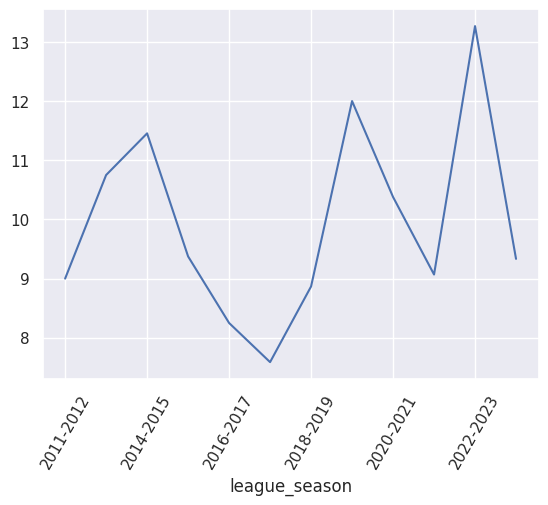

In [29]:
red_score[
    red_score['game_id'].isin(rc_game_total[rc_game_total['home_red_cards'] >= 1]['game_id'].unique())
].groupby('league_season')['home_points_after_home_red'].mean().plot(rot=60)

<Axes: xlabel='league_season'>

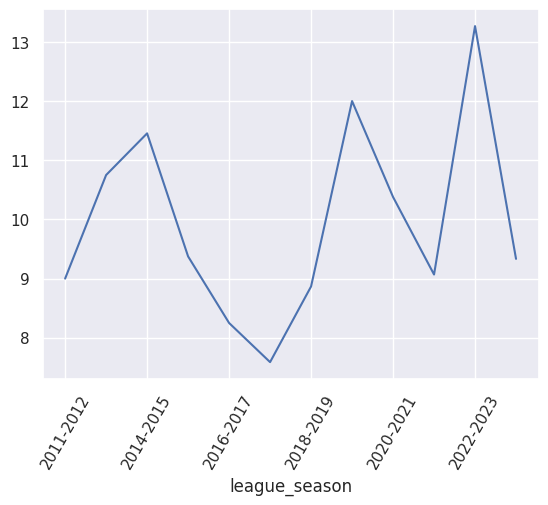

In [33]:
red_score[
    red_score['game_id'].isin(rc_game_total[rc_game_total['home_red_cards'] >= 1]['game_id'].unique())
].groupby('league_season')['home_points_after_home_red'].mean().plot(rot=60)

In [ ]:
rc_game_p1_merge = rc_game_total.merge(
    rc_comm_filt[['game_id', 'Team','Time', 'Home_Score', 'Away_Score', 'first_card_flag']], 
    how='left', 
    left_on=['game_id', 'home_team'], 
    right_on=['game_id', 'Team'],
    suffixes=('', '_home')
)

rc_game_full_merge = rc_game_p1_merge.merge(
    rc_comm_filt[['game_id', 'Team','Time', 'Home_Score', 'Away_Score', 'first_card_flag']], 
    how='left', 
    left_on=['game_id', 'home_team'], 
    right_on=['game_id', 'Team']
)

,game_id,league_id,Time,Team,Player,Event_Type,Home_Score,Away_Score,game_period,first_card_flag
2,597814,270559,54,La Rochelle,Thomas Lavault,Red_Card,22.0,3.0,third_quarter,1.0
3,597814,270559,14,Stade Toulousain,Joshua Brennan,Yellow_Card,NaN,NaN,first_half,1.0
4,597808,270559,38,Toulon,Emerick Setiano,Yellow_Card,12.0,14.0,first_half,1.0
5,597808,270559,38,Stade Toulousain,Rodrigue Neti,Yellow_Card,12.0,14.0,first_half,1.0
6,597786,270559,79,Stade Toulousain,Lucas Tauzin,Yellow_Card,31.0,16.0,fourth_quarter,1.0
...,...,...,...,...,...,...,...,...,...,...
5185,290547,270557,72,Dragons,Charlie Davies,Yellow_Card,3.0,20.0,fourth_quarter,1.0
5186,290547,270557,65,Edinburgh,Allan Dell,Yellow_Card,3.0,17.0,fourth_quarter,1.0
5188,290555,270557,39,Benetton Treviso,Marco Fuser,Yellow_Card,3.0,10.0,first_half,1.0
5189,290496,270557,36,Dragons,Sarel Pretorius,Yellow_Card,10.0,8.0,first_half,1.0


In [ ]:
rc_game_total

In [33]:
test_join = comm_df.merge(first_card_df, on=['game_id', 'Team', 'Event_Type', 'Time'], how='left')
test_join.loc[test_join['first_card_flag'].isnull(), 'first_card_flag'] = 0
test_join

,game_id,league_id,Time,Team,Player,Event_Type,Home_Score,Away_Score,game_period,first_card_flag
0,597814,270559,82,Stade Toulousain,Clement Verge,Try,22.0,8.0,fourth_quarter,0.0
1,597814,270559,76,Stade Toulousain,Juan Cruz Mallia,Yellow_Card,22.0,3.0,fourth_quarter,0.0
2,597814,270559,70,La Rochelle,Judicael Cancoriet,Sub_In,22.0,3.0,fourth_quarter,0.0
3,597814,270559,70,La Rochelle,Levani Botia,Sub_Out,22.0,3.0,fourth_quarter,0.0
4,597814,270559,59,La Rochelle,Ultan Dillane,Sub_In,22.0,3.0,third_quarter,0.0
...,...,...,...,...,...,...,...,...,...,...
185528,290537,270557,30,Zebre,Derick Minnie,Try,13.0,7.0,first_half,0.0
185529,290537,270557,14,Zebre,Federico Ruzza,Try,8.0,7.0,first_half,0.0
185530,290537,270557,8,Dragons,Angus O'Brien,Conversion,3.0,7.0,first_half,0.0
185531,290537,270557,7,Dragons,Cory Hill,Try,3.0,5.0,first_half,0.0


In [30]:
test_join.groupby(['game_id'])['Time'].max().reset_index()

,game_id,Time
0,119090,79
1,119091,79
2,119092,74
3,119093,78
4,119094,72
...,...,...
3941,598223,79
3942,598224,81
3943,598225,78
3944,598226,80


In [26]:
test_join['first_card_flag'].value_counts()

first_card_flag
0.0    185466
1.0        67
Name: count, dtype: int64

In [ ]:
comm_grouped = comm_df.groupby(['game_id', 'Team', 'game_period', 'Event_Type'])['Player'].count().reset_index()

comm_grouped = get_match_time_metrics(comm_grouped, 'Red_Card', 'RC')
comm_grouped = get_match_time_metrics(comm_grouped, 'Yellow_Card', 'YC')
comm_grouped = get_match_time_metrics(comm_grouped, 'Try', 'Try')
comm_grouped = get_match_time_metrics(comm_grouped, 'Sub_In', 'Subs')

comm_cols = list(comm_grouped.columns)
comm_cols.remove('game_period')
comm_cols.remove('Event_Type')
comm_cols.remove('Player')

comm_final = comm_grouped.groupby(['game_id', 'Team'])[[i for i in comm_cols if i not in ['game_id', 'Team']]].sum().reset_index()


In [9]:
total_club_df.columns

Index(['game_id', 'league_id', 'home_team', 'home_team_score', 'away_team',
       'away_team_score', 'home_tries', 'away_tries', 'home_conversions',
       'away_conversions', 'home_penalty_goals', 'away_penalty_goals',
       'home_kick_percent', 'away_kick_percent', 'home_total_meters',
       'away_total_meters', 'home_kfh', 'away_kfh', 'home_pass_meters',
       'away_pass_meters', 'home_runs', 'away_runs', 'home_possession_1h_2h',
       'home_territory_1h_2h', 'home_clean_breaks', 'home_defenders_beaten',
       'home_offloads', 'home_rucks_won', 'home_mauls_won',
       'home_turnovers_conceeded', 'away_possession_1h_2h',
       'away_territory_1h_2h', 'away_clean_breaks', 'away_defenders_beaten',
       'away_offloads', 'away_rucks_won', 'away_mauls_won',
       'away_turnovers_conceeded', 'home_total_possession',
       'home_total_territory', 'away_total_possesion', 'away_total_territory',
       'home_scrum', 'home_lineout', 'away_scrum', 'away_lineout',
       'home_tackle

In [9]:
club_vars = total_club_df[
    [
        'game_id', 'league_id', 
        'home_team', 'away_team', 
        'home_red_cards', 'home_yellow_cards', 
        'away_red_cards', 'away_yellow_cards', 
        'winning_team', 'winning_side', 'season'
    ]
].merge(
    comb_team_info[['team_name', 'team_id', 'rank', 'season']],
    how='left',
    left_on=['home_team', 'season'],
    right_on=['team_name', 'season'],
    suffixes=('', '_home')
).merge(
    comb_team_info[['team_name', 'team_id', 'rank', 'season']],
    how='left',
    left_on=['away_team', 'season'],
    right_on=['team_name', 'season'],
    suffixes=('', '_away')
)

club_vars



,game_id,league_id,home_team,away_team,home_red_cards,home_yellow_cards,away_red_cards,away_yellow_cards,winning_team,winning_side,season,team_name,team_id,rank,team_name_away,team_id_away,rank_away
0,167053,270557,Leinster,Connacht,0.0,0.0,0.0,0.0,Leinster,home,2012,Leinster,NaN,1.0,Connacht,NaN,8.0
1,167046,270557,Ulster,Leinster,0.0,1.0,0.0,0.0,Ulster,home,2012,Ulster,NaN,6.0,Leinster,NaN,1.0
2,167039,270557,Leinster,Zebre,0.0,0.0,0.0,1.0,Leinster,home,2012,Leinster,NaN,1.0,NaN,NaN,NaN
3,167035,270557,Glasgow Warriors,Leinster,0.0,2.0,0.0,1.0,Leinster,away,2012,Glasgow Warriors,NaN,4.0,Leinster,NaN,1.0
4,167027,270557,Ospreys,Leinster,0.0,1.0,0.0,0.0,Ospreys,home,2012,Ospreys,NaN,2.0,Leinster,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4170,597121,267979,Gloucester Rugby,Exeter Chiefs,0.0,0.0,0.0,0.0,Exeter Chiefs,away,2024,Gloucester Rugby,25900.0,9.0,Exeter Chiefs,116227.0,7.0
4171,597107,267979,Exeter Chiefs,Newcastle Falcons,0.0,0.0,0.0,2.0,Exeter Chiefs,home,2024,Exeter Chiefs,116227.0,7.0,Newcastle Falcons,25906.0,10.0
4172,597112,267979,Newcastle Falcons,Leicester Tigers,0.0,0.0,0.0,3.0,Leicester Tigers,away,2024,Newcastle Falcons,25906.0,10.0,Leicester Tigers,25903.0,8.0
4173,597108,267979,Leicester Tigers,Gloucester Rugby,0.0,0.0,0.0,0.0,Gloucester Rugby,away,2024,Leicester Tigers,25903.0,8.0,Gloucester Rugby,25900.0,9.0


In [10]:
# Attach the match commentary data to the Club Variables data 

club_vars = club_vars.merge(
    comm_final,
    left_on=['game_id', 'home_team'],
    right_on=['game_id', 'Team'],
    how='left',
    suffixes=('', '_home')
).merge(
    comm_final,
    left_on=['game_id', 'away_team'],
    right_on=['game_id', 'Team'],
    how='left',
    suffixes=('', '_away')
)

club_vars

,game_id,league_id,home_team,away_team,home_red_cards,home_yellow_cards,away_red_cards,away_yellow_cards,winning_team,winning_side,...,H1_RC_away,Last_20_YC_away,Q3_YC_away,H1_YC_away,Last_20_Try_away,Q3_Try_away,H1_Try_away,Last_20_Subs_away,Q3_Subs_away,H1_Subs_away
0,167053,270557,Leinster,Connacht,0.0,0.0,0.0,0.0,Leinster,home,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0,0.0
1,167046,270557,Ulster,Leinster,0.0,1.0,0.0,0.0,Ulster,home,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,6.0,0.0
2,167039,270557,Leinster,Zebre,0.0,0.0,0.0,1.0,Leinster,home,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,4.0,4.0,0.0
3,167035,270557,Glasgow Warriors,Leinster,0.0,2.0,0.0,1.0,Leinster,away,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,1.0
4,167027,270557,Ospreys,Leinster,0.0,1.0,0.0,0.0,Ospreys,home,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4170,597121,267979,Gloucester Rugby,Exeter Chiefs,0.0,0.0,0.0,0.0,Exeter Chiefs,away,...,0.0,0.0,0.0,0.0,0.0,2.0,3.0,7.0,1.0,0.0
4171,597107,267979,Exeter Chiefs,Newcastle Falcons,0.0,0.0,0.0,2.0,Exeter Chiefs,home,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,6.0,3.0,2.0
4172,597112,267979,Newcastle Falcons,Leicester Tigers,0.0,0.0,0.0,3.0,Leicester Tigers,away,...,0.0,3.0,0.0,0.0,1.0,0.0,2.0,9.0,1.0,1.0
4173,597108,267979,Leicester Tigers,Gloucester Rugby,0.0,0.0,0.0,0.0,Gloucester Rugby,away,...,0.0,0.0,0.0,0.0,1.0,0.0,2.0,3.0,2.0,2.0


In [43]:
def season_binning(season):
    bin_val = None
    if season >= 2012 and season <= 2017:
        bin_val = 0
    else:
        bin_val = 1
    return bin_val

game_df_use = club_vars.loc[:, ~club_vars.columns.duplicated()]
game_df_use = game_df_use[game_df_use['winning_side'] != 'Tie'].reset_index(drop=True)
game_df_use["rank"] = game_df_use.sort_values(["home_team", "season"]).groupby("home_team")["rank"].ffill().bfill()
game_df_use["rank_away"] = game_df_use.sort_values(["away_team", "season"]).groupby("away_team")["rank_away"].ffill().bfill()

game_df_use['season_bin'] = game_df_use['season'].apply(season_binning)
game_df_use['rc_season_interact'] = game_df_use['home_red_cards'] * game_df_use['season_bin']
game_df_use['home_rank_diff'] = game_df_use['rank'] - game_df_use['rank_away']

In [44]:
match_time_metrics = [
    'Last_20_RC', 'Q3_RC', 'H1_RC', 'Last_20_YC', 'Q3_YC', 'H1_YC',
    'Last_20_Try', 'Q3_Try', 'H1_Try', 'Last_20_Subs', 'Q3_Subs', 'H1_Subs',
    'Last_20_RC_away', 'Q3_RC_away', 'H1_RC_away', 'season',
    'Last_20_YC_away', 'Q3_YC_away', 'H1_YC_away', 'Last_20_Try_away',
    'Q3_Try_away', 'H1_Try_away', 'Last_20_Subs_away', 'Q3_Subs_away',
    'H1_Subs_away', 'away_red_cards', 'away_yellow_cards', 'season_bin', 'rc_season_interact',
    'home_rank_diff', 'home_red_cards', 'home_yellow_cards'
]

rank_metrics = ['rank', 'rank_away']

id_feats = ['game_id', 'league_id']

game_df_use = game_df_use[(~game_df_use['Last_20_RC'].isnull()) & (~game_df_use['away_red_cards'].isnull())].reset_index(drop=True)


game_x_df = game_df_use[
    ['game_id', 'league_id'] + rank_metrics + match_time_metrics 
]
game_y_df = game_df_use[['game_id', 'winning_side']]


game_y_df.loc[game_y_df['winning_side'] == 'home', 'target'] = 1
game_y_df.loc[game_y_df['winning_side'] == 'away', 'target'] = 0
game_y_df['target'].value_counts()

x_df_dummy = pd.get_dummies(game_x_df, columns=['league_id'])

/tmp/ipykernel_326468/1856407445.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  game_y_df.loc[game_y_df['winning_side'] == 'home', 'target'] = 1


In [87]:
model_input = x_df_dummy[[
    # 'rc_season_interact',
    'Last_20_RC', 'Q3_RC', 'H1_RC', 
    'Last_20_YC', 'Q3_YC', 'H1_YC', 
    # 'home_red_cards', 
    # 'home_yellow_cards',
    'away_red_cards', 
    'away_yellow_cards', 
    # 'season_bin',
    'season',
    # 'rank', 'rank_away', 
    'league_id_267979', 'league_id_270557', 'league_id_270559', 
    'home_rank_diff'
    ]
]

model_input.fillna(0.0, inplace=True)
# x_train, x_test, y_train, y_test = train_test_split(model_input, game_y_df['target'], stratify=model_input['season'], random_state=4, test_size=0.2)

log_reg = LogisticRegression(random_state=4)
log_reg.fit(
    model_input,
    game_y_df['target']
#     x_train, y_train
)




/tmp/ipykernel_326468/4084125522.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_input.fillna(0.0, inplace=True)
/home/colingrosh/anaconda3/envs/sports_env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=4)

In [88]:
model_input.corr()

,Last_20_RC,Q3_RC,H1_RC,Last_20_YC,Q3_YC,H1_YC,away_red_cards,away_yellow_cards,season,league_id_267979,league_id_270557,league_id_270559,home_rank_diff
Last_20_RC,1.000000,-0.013593,0.016621,-0.000095,0.007896,0.009108,0.046408,0.002685,0.057437,0.035632,-0.045732,0.019538,0.037280
Q3_RC,-0.013593,1.000000,0.042158,-0.011923,-0.002056,0.019969,0.050257,0.034211,0.034757,0.029121,-0.031999,0.010728,-0.006339
H1_RC,0.016621,0.042158,1.000000,-0.014593,-0.019129,-0.006422,0.074283,-0.015039,0.053224,0.000556,-0.024662,0.023645,0.013724
Last_20_YC,-0.000095,-0.011923,-0.014593,1.000000,-0.011865,-0.020549,0.064128,0.107145,-0.019641,0.004252,-0.067850,0.063141,0.004775
Q3_YC,0.007896,-0.002056,-0.019129,-0.011865,1.000000,-0.028503,0.012163,0.041003,0.032432,0.019033,-0.046682,0.032125,0.054965
H1_YC,0.009108,0.019969,-0.006422,-0.020549,-0.028503,1.000000,0.014036,0.061437,-0.004692,0.002778,-0.052914,0.049620,0.087838
away_red_cards,0.046408,0.050257,0.074283,0.064128,0.012163,0.014036,1.000000,-0.008672,0.078737,0.029346,-0.051868,0.029935,-0.014061
away_yellow_cards,0.002685,0.034211,-0.015039,0.107145,0.041003,0.061437,-0.008672,1.000000,-0.040850,-0.058648,-0.116821,0.155060,-0.068559
season,0.057437,0.034757,0.053224,-0.019641,0.032432,-0.004692,0.078737,-0.040850,1.000000,0.401626,-0.252783,-0.035794,0.007230
league_id_267979,0.035632,0.029121,0.000556,0.004252,0.019033,0.002778,0.029346,-0.058648,0.401626,1.000000,-0.323829,-0.386939,0.013192


Brier Score: 0.17738416506782867
AUC Score: 0.7538855726135957


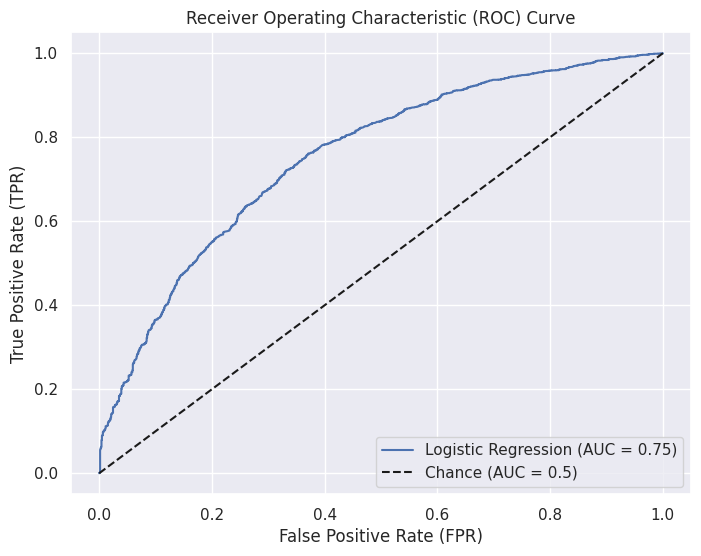

In [89]:
test_output = log_reg.predict_proba(model_input)

b_score = brier_score_loss(game_y_df['target'], test_output[:,1:])
auc = roc_auc_score(game_y_df['target'], test_output[:,1:])
fpr, tpr, thresholds = roc_curve(game_y_df['target'], test_output[:,1:])
print(f"Brier Score: {b_score}")
print(f"AUC Score: {auc}")

plt.figure(figsize=(8, 6))
# Plot the ROC curve with AUC label
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.2f})")
# Plot the random chance line (AUC = 0.5)
plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.5)')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [90]:
from sklearn.metrics import log_loss 

log_score = log_loss(game_y_df['target'], test_output)
log_score

0.5314138153443367

In [81]:
bool_cols = model_input.select_dtypes(include=[bool])
model_input[bool_cols.columns] = bool_cols.astype(int)

/tmp/ipykernel_326468/1258602473.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_input[bool_cols.columns] = bool_cols.astype(int)


In [85]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [86]:
test_vif = model_input.copy()
test_vif['constant'] = 1

vif_df = pd.DataFrame()

vif_df["feature"] = test_vif.columns
vif_df["VIF"] = [variance_inflation_factor(test_vif.values, i) for i in range(test_vif.shape[1])]

print(vif_df)



               feature       VIF
0   rc_season_interact  3.421634
1           Last_20_RC  1.903450
2                Q3_RC  1.694349
3                H1_RC  1.748299
4           Last_20_YC  1.022566
5                Q3_YC  1.010056
6                H1_YC  1.018116
7       away_red_cards  1.023911
8    away_yellow_cards  1.049481
9               season  1.247511
10    league_id_267979       inf
11    league_id_270557       inf
12    league_id_270559       inf
13      home_rank_diff  1.019565
14            constant  0.000000


/home/colingrosh/anaconda3/envs/sports_env/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
/home/colingrosh/anaconda3/envs/sports_env/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


In [82]:
# Add a constant (intercept) term to the features, which statsmodels requires
X_with_constant = sm.add_constant(np.asarray(model_input))

# Create and fit the statsmodels GLM model (Logistic Regression with Binomial family)
# The Logit class is also a valid option
model_sm = sm.GLM(np.asarray(game_y_df['target']), X_with_constant, family=sm.families.Binomial())
results = model_sm.fit()

# Print the summary
print(results.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                 3899
Model:                            GLM   Df Residuals:                     3885
Model Family:                Binomial   Df Model:                           13
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2070.5
Date:                Wed, 04 Feb 2026   Deviance:                       4141.0
Time:                        23:03:41   Pearson chi2:                 3.94e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.1663
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.0611     16.751      0.660      0.5

In [53]:
model_input.columns

Index(['rc_season_interact', 'Last_20_RC', 'Q3_RC', 'H1_RC', 'Last_20_YC',
       'Q3_YC', 'H1_YC', 'home_yellow_cards', 'away_red_cards',
       'away_yellow_cards', 'season_bin', 'rank', 'rank_away',
       'league_id_267979', 'league_id_270557', 'league_id_270559',
       'home_rank_diff'],
      dtype='object')

In [28]:
X_with_constant.shape

(3899, 15)

In [33]:
model_preds.reshape(-1,1)

array([[0.87746107],
       [0.47324989],
       [0.94110482],
       ...,
       [0.61749029],
       [0.68220446],
       [0.70017773]])

In [41]:
model_preds = results.predict(X_with_constant).reshape(-1,1)
brier_score_loss(game_y_df['target'], model_preds)

np.float64(0.17718728875905093)

In [66]:
model_input.columns

Index(['Last_20_RC', 'Q3_RC', 'H1_RC', 'Last_20_YC', 'Q3_YC', 'H1_YC',
       'away_red_cards', 'away_yellow_cards', 'season', 'rank', 'rank_away',
       'league_id_267979', 'league_id_270557', 'league_id_270559'],
      dtype='object')

In [54]:
model_input.columns[2]

'H1_RC'

In [53]:
results.pvalues[2]

np.float64(0.08314725396314772)

In [42]:
results.pvalues.argsort()

array([10, 11,  7,  5,  6,  2,  8,  3,  4, 14,  0, 13,  9, 12,  1])

In [63]:
results.params

array([ 1.01129212e+01, -1.26476774e-01, -5.55730652e-01, -3.28713345e-01,
        8.10351098e-02, -2.67778454e-01, -2.41403484e-01,  5.43383410e-01,
        8.48916349e-02, -6.26070175e-03, -1.80118424e-01,  1.79449937e-01,
        3.14855835e+00,  3.19673356e+00,  3.76762925e+00])

In [65]:
dir(results)[85:]

['remove_data',
 'resid_anscombe',
 'resid_anscombe_scaled',
 'resid_anscombe_unscaled',
 'resid_deviance',
 'resid_pearson',
 'resid_response',
 'resid_working',
 'save',
 'scale',
 'score_test',
 'summary',
 'summary2',
 't_test',
 't_test_pairwise',
 'tvalues',
 'use_t',
 'wald_test',
 'wald_test_terms']

In [35]:
model_input.columns

Index(['Last_20_RC', 'Q3_RC', 'H1_RC', 'Last_20_YC', 'Q3_YC', 'H1_YC',
       'away_red_cards', 'away_yellow_cards', 'season', 'rank', 'rank_away',
       'league_id_267979', 'league_id_270557', 'league_id_270559'],
      dtype='object')

In [37]:
test_output = log_reg.predict_proba(x_test)

In [40]:
test_output[:,1:]

array([[0.77097908],
       [0.58326901],
       [0.80892903],
       [0.7550711 ],
       [0.93272385],
       [0.76478775],
       [0.26932788],
       [0.64056608],
       [0.85020252],
       [0.64864759],
       [0.75534779],
       [0.87158786],
       [0.90661992],
       [0.68128565],
       [0.25552734],
       [0.83423674],
       [0.67261006],
       [0.76932459],
       [0.64952667],
       [0.59406769],
       [0.49860401],
       [0.49050412],
       [0.85748489],
       [0.43468734],
       [0.6484242 ],
       [0.45140889],
       [0.64924039],
       [0.8795317 ],
       [0.58491511],
       [0.57351322],
       [0.66838258],
       [0.60033626],
       [0.53921179],
       [0.27812863],
       [0.67122561],
       [0.66997979],
       [0.63301109],
       [0.66707392],
       [0.79830772],
       [0.92852244],
       [0.74122752],
       [0.87020067],
       [0.315037  ],
       [0.71841129],
       [0.38209429],
       [0.89379533],
       [0.62911559],
       [0.518

In [ ]:
x_train

,Last_20_RC,Q3_RC,H1_RC,Last_20_YC,Q3_YC,H1_YC,away_red_cards,away_yellow_cards,season,rank,rank_away,league_id_267979,league_id_270557,league_id_270559
2364,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2017,9.0,3.0,False,False,True
3741,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2021,9.0,12.0,True,False,False
3608,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2020,8.0,2.0,True,False,False
1411,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2016,8.0,9.0,False,True,False
3518,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022,7.0,10.0,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3568,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2021,10.0,4.0,True,False,False
2713,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2022,9.0,1.0,False,False,True
352,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2022,1.0,6.0,False,True,False
1589,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2016,1.0,10.0,False,False,True


In [ ]:
x_train.columns

Index(['Last_20_RC', 'Q3_RC', 'H1_RC', 'Last_20_YC', 'Q3_YC', 'H1_YC',
       'away_red_cards', 'away_yellow_cards', 'season', 'rank', 'rank_away',
       'league_id_267979', 'league_id_270557', 'league_id_270559'],
      dtype='object')

In [ ]:
log_reg.coef_

array([[-3.63085183e-02, -1.81298049e-01, -2.15971839e-01,
         1.59424529e-01, -3.81584098e-01, -1.89106247e-01,
         4.31932717e-01,  7.96633048e-02,  3.60915584e-04,
        -1.63466557e-01,  1.72269575e-01, -3.48927148e-01,
        -8.79662996e-02,  4.38468349e-01]])

In [ ]:
x_train.columns[5]

'H1_YC'

In [ ]:
log_reg.coef_[0][5]

np.float64(-0.18910624727914008)

np.float64(0.17047917744081964)

In [ ]:
test_output = log_reg.predict_proba(x_test)

brier_score_loss(y_test, test_output[:,1:])
auc = roc_auc_score(y_test, test_output[:,1:])
fpr, tpr, thresholds = roc_curve(y_test, test_output[:,1:])


plt.figure(figsize=(8, 6))
# Plot the ROC curve with AUC label
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.2f})")
# Plot the random chance line (AUC = 0.5)
plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.5)')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


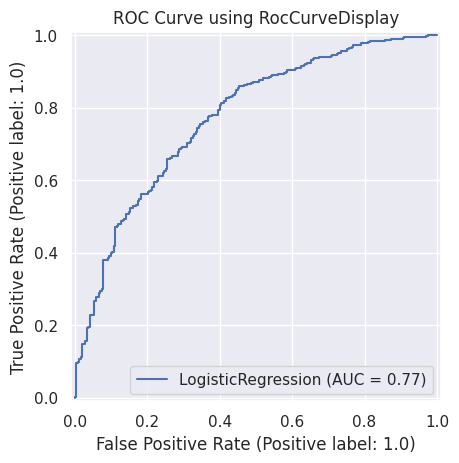

In [ ]:
RocCurveDisplay.from_estimator(log_reg, x_test, y_test)
plt.title('ROC Curve using RocCurveDisplay')
plt.show()

In [ ]:
test_output

array([[0.12452696, 0.87547304],
       [0.52367099, 0.47632901],
       [0.05989088, 0.94010912],
       ...,
       [0.38832893, 0.61167107],
       [0.32421274, 0.67578726],
       [0.30573152, 0.69426848]])

In [ ]:
test_output[:,1:]

array([[0.87547304],
       [0.47632901],
       [0.94010912],
       ...,
       [0.61167107],
       [0.67578726],
       [0.69426848]])

In [ ]:
game_y_df

,game_id,winning_side,target
0,167053,home,1.0
1,167046,home,1.0
2,167039,home,1.0
3,167035,away,0.0
4,167027,home,1.0
...,...,...,...
4057,597121,away,0.0
4058,597107,home,1.0
4059,597112,away,0.0
4060,597108,away,0.0


In [ ]:
log_reg.predict_proba(model_input)

array([[0.12651334, 0.87348666],
       [0.60457919, 0.39542081],
       [0.05969532, 0.94030468],
       ...,
       [0.365974  , 0.634026  ],
       [0.30315796, 0.69684204],
       [0.28491123, 0.71508877]])